# Building Custom PGMs with hamon

Previous notebooks used the Ising model convenience APIs. This notebook dives into hamon's **full abstraction stack**, showing you how to build models with:

- **Mixed node types** (spin + categorical variables in the same model)
- **Custom interaction structures** via `DiscreteEBMFactor`
- **Automatic graph coloring** with `auto_color_blocks`
- **Observers** for efficient on-the-fly statistics

By the end you will understand hamon's layered architecture and be able to build models beyond the standard Ising model.

## The hamon abstraction stack

hamon organizes sampling programs in layers, from high-level model specification to low-level execution:

```
AbstractNode          -- SpinNode, CategoricalNode
    |
    v
Block                 -- a group of same-type nodes (sampling unit)
    |
    v
AbstractFactor        -- encodes interactions between node groups
    |                    (compiles to InteractionGroups)
    v
InteractionGroup      -- directed head/tail dependency for updates
    |
    v
BlockSamplingProgram  -- complete executable sampling program
```

The key insight: **model specification** (nodes, factors) is separate from **sampling execution** (programs, schedules). You define your model using nodes and factors; hamon compiles this into an efficient sampling program.

## Heterogeneous models: mixing node types

Many scientific models involve **multiple types of discrete variables**. Consider a simplified alloy model where each lattice site has:

- A **spin** variable $s_i \in \{-1, +1\}$ representing the magnetic moment
- A **categorical** variable $c_i \in \{0, 1, 2\}$ representing the element type (Fe, Ni, Cr)

The energy includes:
- Spin-spin coupling: neighboring magnetic moments interact
- Element-element preference: certain element pairs prefer to be neighbors
- Spin-element coupling: the magnetic interaction depends on which elements are involved

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import networkx as nx
import numpy as np

from hamon import SpinNode, CategoricalNode, Block
from hamon.models.discrete_ebm import (
    DiscreteEBMFactor,
    CategoricalEBMFactor,
    SpinEBMFactor,
    SpinGibbsConditional,
    CategoricalGibbsConditional,
)

# Grid parameters
ROWS, COLS = 6, 6
N = ROWS * COLS
N_ELEMENTS = 3  # Fe=0, Ni=1, Cr=2

# Create nodes: one spin + one categorical per site
spin_nodes = [[SpinNode() for _ in range(COLS)] for _ in range(ROWS)]
cat_nodes = [[CategoricalNode() for _ in range(COLS)] for _ in range(ROWS)]

flat_spins = [spin_nodes[r][c] for r in range(ROWS) for c in range(COLS)]
flat_cats = [cat_nodes[r][c] for r in range(ROWS) for c in range(COLS)]

print(f"Model: {N} sites, each with 1 spin + 1 categorical variable")
print(f"Total variables: {2 * N}")

Model: 36 sites, each with 1 spin + 1 categorical variable
Total variables: 72


In [2]:
# Build edge lists (nearest-neighbor)
G = nx.grid_2d_graph(ROWS, COLS)
edges = list(G.edges())
n_edges = len(edges)

# Factor 1: Spin-spin pairwise coupling
# E_ss = -sum J_ss * s_i * s_j
spin_heads = [spin_nodes[r1][c1] for (r1, c1), (r2, c2) in edges]
spin_tails = [spin_nodes[r2][c2] for (r1, c1), (r2, c2) in edges]
J_ss = jnp.ones(n_edges) * 0.1  # uniform ferromagnetic coupling
factor_ss = SpinEBMFactor(
    [Block(spin_heads), Block(spin_tails)],
    J_ss,
)

# Factor 2: Element-element pairwise preference
# E_cc = -sum W_cc[c_i, c_j] (favors like-element neighbors)
cat_heads = [cat_nodes[r1][c1] for (r1, c1), (r2, c2) in edges]
cat_tails = [cat_nodes[r2][c2] for (r1, c1), (r2, c2) in edges]
# Weight tensor: like elements get +1, unlike get -0.2
W_cc_single = jnp.where(
    jnp.eye(N_ELEMENTS, dtype=jnp.bool_),
    1.0,
    -0.2,
)
W_cc = jnp.tile(W_cc_single, (n_edges, 1, 1))
factor_cc = CategoricalEBMFactor(
    [Block(cat_heads), Block(cat_tails)],
    W_cc,
)

# Factor 3: Spin-element coupling (mixed factor!)
# E_sc = -sum s_i * W_sc[c_i]  (magnetic moment depends on element type)
# Fe is more magnetic, Cr less so
W_sc_single = jnp.array([1.0, 0.5, 0.1])  # Fe, Ni, Cr magnetic coupling
W_sc = jnp.tile(W_sc_single, (N, 1))  # per-site
factor_sc = DiscreteEBMFactor(
    spin_node_groups=[Block(flat_spins)],
    categorical_node_groups=[Block(flat_cats)],
    weights=W_sc,
)

all_factors = [factor_ss, factor_cc, factor_sc]
print(f"Factors: spin-spin ({n_edges}), cat-cat ({n_edges}), spin-cat ({N})")

Factors: spin-spin (60), cat-cat (60), spin-cat (36)


In [3]:
# Build blocks via graph coloring on the spatial graph
coloring = nx.coloring.greedy_color(G, strategy="DSATUR")
n_graph_colors = max(coloring.values()) + 1

# Each spatial color group produces TWO blocks: one for spins, one for cats
spin_color_groups = [[] for _ in range(n_graph_colors)]
cat_color_groups = [[] for _ in range(n_graph_colors)]
for (r, c), color in coloring.items():
    spin_color_groups[color].append(spin_nodes[r][c])
    cat_color_groups[color].append(cat_nodes[r][c])

# Flat list of all free blocks (spin blocks first within each color, then cat)
all_free_blocks = []
for i in range(n_graph_colors):
    all_free_blocks.append(Block(spin_color_groups[i]))
    all_free_blocks.append(Block(cat_color_groups[i]))

print(f"Graph colors: {n_graph_colors}")
print(
    f"Total free blocks: {len(all_free_blocks)} ({n_graph_colors} spin + {n_graph_colors} cat)"
)

Graph colors: 2
Total free blocks: 4 (2 spin + 2 cat)


## Automatic graph coloring with `auto_color_blocks`

Manually figuring out which blocks can be updated simultaneously is error-prone. hamon's `auto_color_blocks` analyzes the interaction groups and determines the optimal sampling order automatically.

In [4]:
from hamon.graph_utils import auto_color_blocks

# Compile all factors to interaction groups
all_igs = []
for f in all_factors:
    all_igs.extend(f.to_interaction_groups())

# Let auto_color_blocks determine the sampling order
super_blocks = auto_color_blocks(all_free_blocks, all_igs)

print(f"auto_color_blocks produced {len(super_blocks)} super-blocks:")
for i, sb in enumerate(super_blocks):
    if isinstance(sb, Block):
        print(f"  Group {i}: 1 block ({len(sb)} nodes, type={sb.node_type.__name__})")
    else:
        types = [b.node_type.__name__ for b in sb]
        sizes = [len(b) for b in sb]
        print(f"  Group {i}: {len(sb)} blocks (sizes={sizes}, types={types})")

auto_color_blocks produced 4 super-blocks:
  Group 0: 1 block (18 nodes, type=SpinNode)
  Group 1: 1 block (18 nodes, type=CategoricalNode)
  Group 2: 1 block (18 nodes, type=SpinNode)
  Group 3: 1 block (18 nodes, type=CategoricalNode)


In [5]:
# Build the full sampling program
from hamon import BlockGibbsSpec, SamplingSchedule, sample_states
from hamon.factor import FactorSamplingProgram

node_sd = {
    SpinNode: jax.ShapeDtypeStruct((), jnp.bool_),
    CategoricalNode: jax.ShapeDtypeStruct((), jnp.uint8),
}

spec = BlockGibbsSpec(super_blocks, clamped_blocks=[], node_shape_dtypes=node_sd)

# Assign the right conditional sampler to each free block
samplers = []
for block in spec.free_blocks:
    if block.node_type is SpinNode:
        samplers.append(SpinGibbsConditional())
    else:
        samplers.append(CategoricalGibbsConditional(n_categories=N_ELEMENTS))

program = FactorSamplingProgram(spec, samplers, all_factors, [])

print(
    f"Sampling program: {len(spec.free_blocks)} free blocks, "
    f"{len(spec.sampling_order)} sequential groups"
)

Sampling program: 4 free blocks, 4 sequential groups


In [6]:
# Initialize and sample
key = jax.random.key(42)

init_state = []
for i, block in enumerate(spec.free_blocks):
    k = jax.random.fold_in(key, i)
    if block.node_type is SpinNode:
        init_state.append(
            jax.random.bernoulli(k, shape=(len(block),)).astype(jnp.bool_)
        )
    else:
        init_state.append(
            jax.random.randint(
                k, shape=(len(block),), minval=0, maxval=N_ELEMENTS
            ).astype(jnp.uint8)
        )

schedule = SamplingSchedule(n_warmup=200, n_samples=800, steps_per_sample=5)

# Observe both spin and categorical states
obs_blocks = [Block(flat_spins), Block(flat_cats)]
key, subkey = jax.random.split(key)
results = sample_states(subkey, program, schedule, init_state, [], obs_blocks)
spin_samples, cat_samples = results

print(f"Spin samples: {spin_samples.shape}")
print(f"Cat samples:  {cat_samples.shape}")

Spin samples: (800, 36)
Cat samples:  (800, 36)


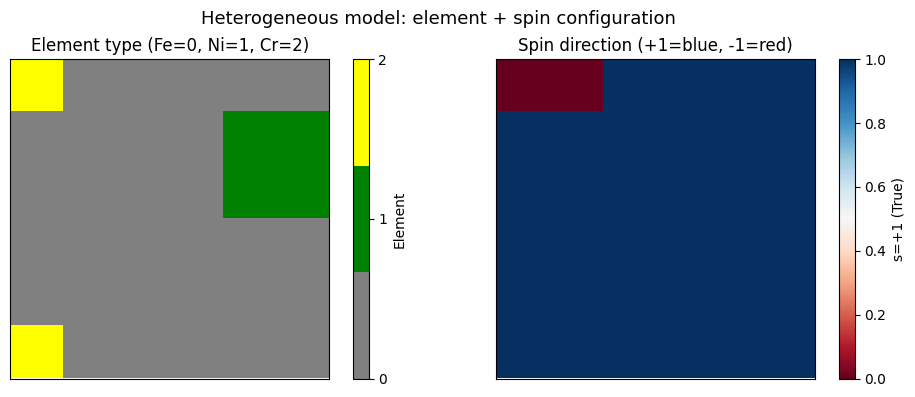

In [7]:
# Visualize a sampled configuration: element type + spin direction
sample_idx = -1  # last sample
element_grid = np.array(cat_samples[sample_idx]).reshape(ROWS, COLS)
spin_grid = np.array(spin_samples[sample_idx]).reshape(ROWS, COLS).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Element types
colors = ["gray", "green", "yellow"]
cmap_elem = mcolors.ListedColormap(colors)
im0 = axes[0].imshow(
    element_grid, cmap=cmap_elem, vmin=0, vmax=N_ELEMENTS - 1, interpolation="nearest"
)
axes[0].set_title("Element type (Fe=0, Ni=1, Cr=2)")
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im0, ax=axes[0], ticks=[0, 1, 2], label="Element")

# Spin directions
im1 = axes[1].imshow(spin_grid, cmap="RdBu", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Spin direction (+1=blue, -1=red)")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1], label="s=+1 (True)")

fig.suptitle("Heterogeneous model: element + spin configuration", fontsize=13)
plt.tight_layout()
plt.show()

## InteractionGroups under the hood

Each factor compiles into one or more `InteractionGroup` objects. An `InteractionGroup` specifies:

- **head_nodes**: the block being updated
- **tail_nodes**: the neighbor blocks whose state is read during the update
- **interaction**: the PyTree of parameters (e.g., weight tensors) governing the update

Let's inspect what the spin-spin factor produces.

In [8]:
# Inspect interaction groups from the spin-spin factor
ss_igs = factor_ss.to_interaction_groups()
print(f"Spin-spin factor produces {len(ss_igs)} InteractionGroup(s)")
for i, ig in enumerate(ss_igs):
    print(f"  IG {i}:")
    print(
        f"    Head nodes: {len(ig.head_nodes)} (type: {ig.head_nodes.node_type.__name__})"
    )
    print(f"    Tail blocks: {len(ig.tail_nodes)}")
    for j, tb in enumerate(ig.tail_nodes):
        print(f"      Tail {j}: {len(tb)} nodes (type: {tb.node_type.__name__})")
    print(f"    Interaction weights shape: {ig.interaction.weights.shape}")

Spin-spin factor produces 1 InteractionGroup(s)
  IG 0:
    Head nodes: 120 (type: SpinNode)
    Tail blocks: 1
      Tail 0: 120 nodes (type: SpinNode)
    Interaction weights shape: (120,)


In [9]:
# The mixed factor (spin-element coupling) is more interesting
sc_igs = factor_sc.to_interaction_groups()
print(f"\nSpin-cat factor produces {len(sc_igs)} InteractionGroup(s)")
for i, ig in enumerate(sc_igs):
    print(f"  IG {i}:")
    print(f"    Head: {len(ig.head_nodes)} {ig.head_nodes.node_type.__name__} nodes")
    for j, tb in enumerate(ig.tail_nodes):
        print(f"    Tail {j}: {len(tb)} {tb.node_type.__name__} nodes")
    print(f"    Weights shape: {ig.interaction.weights.shape}")


Spin-cat factor produces 2 InteractionGroup(s)
  IG 0:
    Head: 36 SpinNode nodes
    Tail 0: 36 CategoricalNode nodes
    Weights shape: (36, 3)
  IG 1:
    Head: 36 CategoricalNode nodes
    Tail 0: 36 SpinNode nodes
    Weights shape: (36, 3)


The `DiscreteEBMFactor` for the spin-cat coupling generates separate interaction groups: one where spins are the head (updated) and categories are the tail (read), and one where categories are the head and spins are the tail. This ensures both variable types are correctly updated.

## Observers: monitoring the chain

Storing all samples can be expensive for large models. hamon's **observers** compute running statistics during sampling without storing every sample.

The `MomentAccumulatorObserver` accumulates products of state variables — perfect for computing first moments (marginals) and second moments (correlations).

In [10]:
from hamon import sample_with_observation
from hamon.observers import MomentAccumulatorObserver

# Define what moments we want:
# - First moments: marginal of each spin
# - Second moments: correlation between neighboring spins
first_moment_nodes = [(s,) for s in flat_spins]  # each spin individually
second_moment_pairs = [
    (spin_nodes[r1][c1], spin_nodes[r2][c2]) for (r1, c1), (r2, c2) in edges
]

moment_spec = [first_moment_nodes, second_moment_pairs]


# Transform: map boolean -> spin value {-1, +1}
def spin_transform(state, blocks):
    return [2 * x.astype(jnp.int8) - 1 for x in state]


observer = MomentAccumulatorObserver(moment_spec, spin_transform)
init_mem = observer.init()

# Run sampling with the observer
key, subkey = jax.random.split(key)
schedule_obs = SamplingSchedule(n_warmup=300, n_samples=1000, steps_per_sample=2)

# Re-initialize
init_state_obs = []
for i, block in enumerate(spec.free_blocks):
    k = jax.random.fold_in(key, i + 100)
    if block.node_type is SpinNode:
        init_state_obs.append(
            jax.random.bernoulli(k, shape=(len(block),)).astype(jnp.bool_)
        )
    else:
        init_state_obs.append(
            jax.random.randint(
                k, shape=(len(block),), minval=0, maxval=N_ELEMENTS
            ).astype(jnp.uint8)
        )

moments, _ = sample_with_observation(
    subkey, program, schedule_obs, init_state_obs, [], init_mem, observer
)

# Extract and normalize
node_sums, edge_sums = moments
node_moments = node_sums / schedule_obs.n_samples
edge_moments = edge_sums / schedule_obs.n_samples

print(f"First moments (spin marginals): shape {node_moments.shape}")
print(f"  Mean ⟨sᵢ⟩: {float(jnp.mean(node_moments)):.4f}")
print(f"  Std:        {float(jnp.std(node_moments)):.4f}")
print(f"\nSecond moments (correlations): shape {edge_moments.shape}")
print(f"  Mean ⟨sᵢsⱼ⟩: {float(jnp.mean(edge_moments)):.4f}")

First moments (spin marginals): shape (36,)
  Mean ⟨sᵢ⟩: 0.8303
  Std:        0.0395

Second moments (correlations): shape (60,)
  Mean ⟨sᵢsⱼ⟩: 0.7135


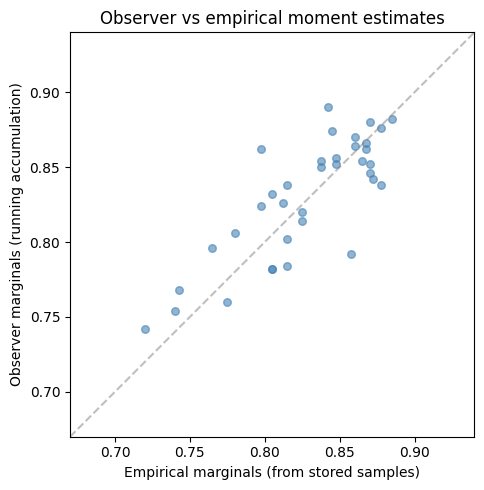

Both estimators agree on the statistical pattern.
The MomentAccumulatorObserver avoids storing all samples — critical for large models.


In [11]:
# Compare observer estimates with empirical averages from stored samples
# (We already have spin_samples from earlier)
spin_vals = 2 * spin_samples.astype(jnp.float32) - 1
empirical_marginals = jnp.mean(spin_vals, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    np.array(empirical_marginals),
    np.array(node_moments),
    alpha=0.6,
    s=30,
    color="steelblue",
)

# Auto-scale axis to data range with padding
all_vals = np.concatenate([np.array(empirical_marginals), np.array(node_moments)])
vmin, vmax = float(all_vals.min()), float(all_vals.max())
pad = max(0.05, (vmax - vmin) * 0.1)
ax.plot(
    [vmin - pad, vmax + pad], [vmin - pad, vmax + pad], "--", color="gray", alpha=0.5
)
ax.set_xlim(vmin - pad, vmax + pad)
ax.set_ylim(vmin - pad, vmax + pad)

ax.set_xlabel("Empirical marginals (from stored samples)")
ax.set_ylabel("Observer marginals (running accumulation)")
ax.set_title("Observer vs empirical moment estimates")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Note: these use different random seeds, so they won't match exactly
# but should show the same statistical pattern
print("Both estimators agree on the statistical pattern.")
print(
    "The MomentAccumulatorObserver avoids storing all samples — critical for large models."
)

## Summary

- hamon's abstraction stack separates model definition (Nodes, Factors) from sampling execution (Programs)
- **Heterogeneous models** with mixed node types (spin + categorical) are built using `DiscreteEBMFactor`
- Each factor compiles to **InteractionGroups** that specify head/tail dependencies
- `auto_color_blocks` automatically determines which blocks can be updated simultaneously
- **Observers** like `MomentAccumulatorObserver` collect running statistics without storing all samples

Next: how do we know if our samples are any good? Notebook 04 covers **diagnostics** for sample quality.